In [7]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-04-09 091915.png to Screenshot 2026-04-09 091915.png


In [8]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-04-09 091930.png to Screenshot 2026-04-09 091930.png


Loading images...
Left Image Shape: (321, 405, 3)
Right Image Shape: (320, 399, 3)

Fixing image size mismatch...
Resized to: 320 x 399

Computing disparity...
✓ Disparity computed

Computing depth map...
✓ Depth map computed

Refining depth map...
✓ Refinement done

Normalizing results...

Displaying results...


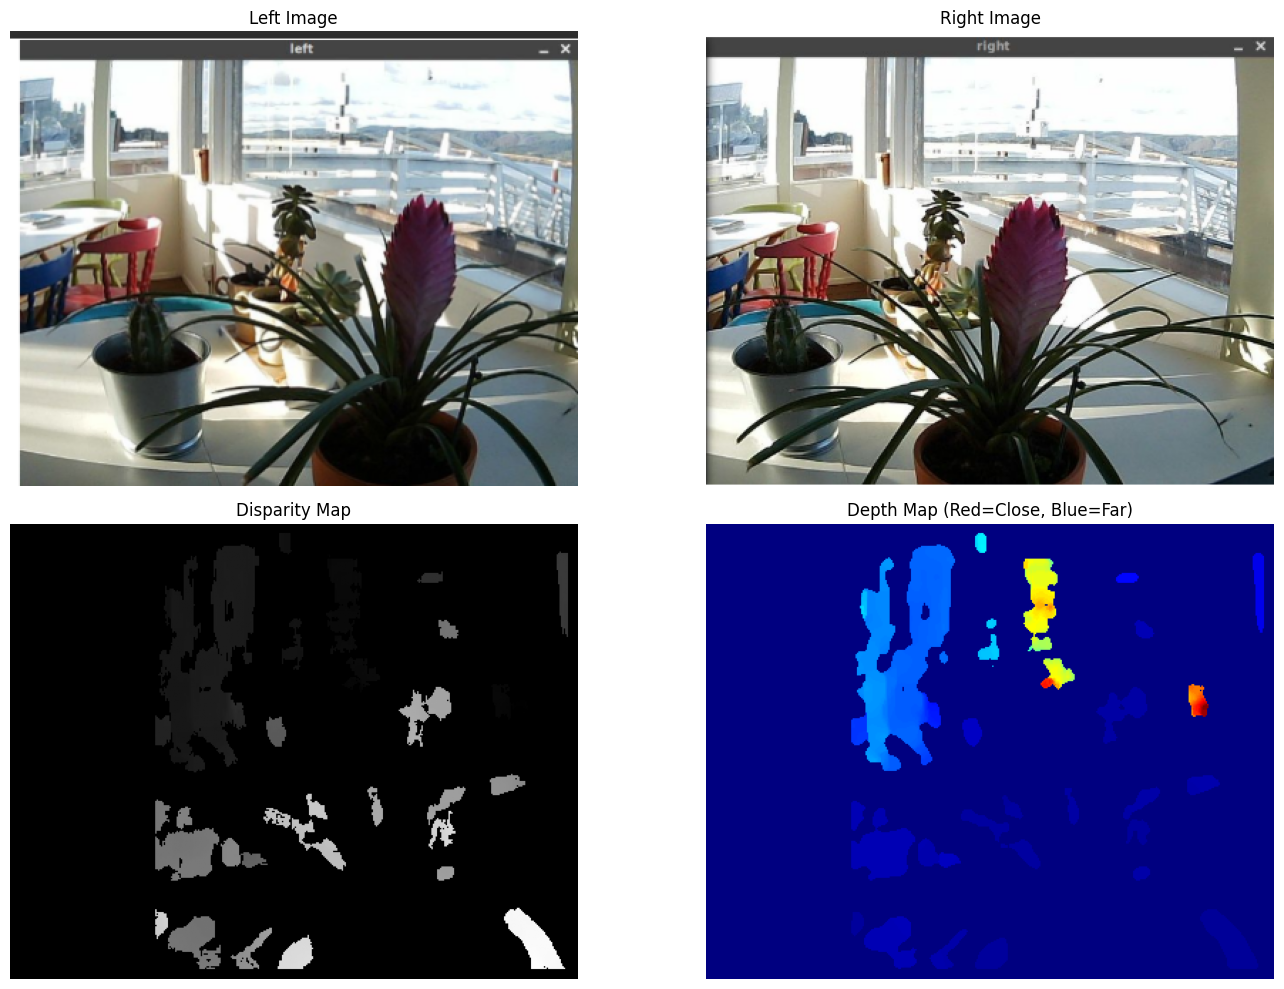


✅ DEPTH ESTIMATION COMPLETED SUCCESSFULLY!


In [10]:
# ============================================================
# COMPLETE STEREO VISION & DEPTH ESTIMATION (COLAB READY)
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: LOAD IMAGES
# ============================================================

def load_images():
    print("Loading images...")

    left = cv2.imread("/content/Screenshot 2026-04-09 091915.png")
    right = cv2.imread("/content/Screenshot 2026-04-09 091930.png")

    if left is None or right is None:
        print("❌ Please upload left.png and right.png")
        return None, None

    print(f"Left Image Shape: {left.shape}")
    print(f"Right Image Shape: {right.shape}")

    return left, right


# ============================================================
# STEP 2: PREPROCESS (FIX SIZE ISSUE)
# ============================================================

def preprocess(left, right):
    print("\nFixing image size mismatch...")

    h = min(left.shape[0], right.shape[0])
    w = min(left.shape[1], right.shape[1])

    left = cv2.resize(left, (w, h))
    right = cv2.resize(right, (w, h))

    print(f"Resized to: {h} x {w}")

    left_gray = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)
    right_gray = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)

    return left, right, left_gray, right_gray


# ============================================================
# STEP 3: COMPUTE DISPARITY
# ============================================================

def compute_disparity(left_gray, right_gray):
    print("\nComputing disparity...")

    stereo = cv2.StereoBM_create(numDisparities=16*6, blockSize=15)

    stereo.setPreFilterCap(61)
    stereo.setTextureThreshold(10)
    stereo.setUniquenessRatio(15)
    stereo.setSpeckleRange(32)
    stereo.setSpeckleWindowSize(100)
    stereo.setMinDisparity(0)

    disparity = stereo.compute(left_gray, right_gray)

    print("✓ Disparity computed")
    return disparity


# ============================================================
# STEP 4: DEPTH MAP
# ============================================================

def compute_depth(disparity, baseline=65.0, focal_length=1000.0):
    print("\nComputing depth map...")

    disparity = np.float32(disparity) / 16.0
    disparity[disparity <= 0] = 0.1

    depth = (baseline * focal_length) / disparity
    depth[depth > 50000] = 0

    print("✓ Depth map computed")
    return disparity, depth


# ============================================================
# STEP 5: FILTERING
# ============================================================

def refine_depth(depth):
    print("\nRefining depth map...")

    depth = cv2.medianBlur(depth.astype(np.float32), 5)
    depth = cv2.bilateralFilter(depth, 9, 75, 75)

    print("✓ Refinement done")
    return depth


# ============================================================
# STEP 6: NORMALIZATION
# ============================================================

def normalize(disparity, depth):
    print("\nNormalizing results...")

    disp_norm = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX)
    disp_norm = np.uint8(disp_norm)

    depth_norm = cv2.normalize(depth, None, 0, 255, cv2.NORM_MINMAX)
    depth_norm = np.uint8(depth_norm)

    depth_color = cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)

    return disp_norm, depth_color


# ============================================================
# STEP 7: VISUALIZATION
# ============================================================

def visualize(left, right, disparity, depth):
    print("\nDisplaying results...")

    plt.figure(figsize=(15,10))

    plt.subplot(2,2,1)
    plt.imshow(cv2.cvtColor(left, cv2.COLOR_BGR2RGB))
    plt.title("Left Image")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(cv2.cvtColor(right, cv2.COLOR_BGR2RGB))
    plt.title("Right Image")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(disparity, cmap='gray')
    plt.title("Disparity Map")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(cv2.cvtColor(depth, cv2.COLOR_BGR2RGB))
    plt.title("Depth Map (Red=Close, Blue=Far)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# MAIN FUNCTION
# ============================================================

def main():
    left, right = load_images()
    if left is None:
        return

    left, right, left_gray, right_gray = preprocess(left, right)

    disparity = compute_disparity(left_gray, right_gray)

    disparity, depth = compute_depth(disparity)

    depth = refine_depth(depth)

    disp_norm, depth_color = normalize(disparity, depth)

    visualize(left, right, disp_norm, depth_color)

    print("\n✅ DEPTH ESTIMATION COMPLETED SUCCESSFULLY!")


# ============================================================
# RUN
# ============================================================

main()